# 4.2 Subsection

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import label
from math import radians, sin, cos, asin, sqrt

# -----------------------------
# 1. Load GEBCO subset
# -----------------------------
gebco_path = (
    "arctic_routing_paperA/data/raw/bathymetry_gebco/GEBCO_2024_arctic_corridor.nc"
)  # adjust to your project structure

ds = xr.open_dataset(gebco_path)

lat_full = ds["lat"].values
lon_full = ds["lon"].values
elev_full = ds["elevation"].values  # GEBCO elevation: negative = depth

print("Lat range:", lat_full.min(), lat_full.max())
print("Lon range:", lon_full.min(), lon_full.max())

# -----------------------------
# 2. Define 0.5° routing grid
# -----------------------------
dlat = 0.5
dlon = 0.5

lat_rg = np.arange(40.5, 84.5 + 1e-6, dlat)
lon_rg = np.arange(-19.5, 179.5 + 1e-6, dlon)

lon_rg_2d, lat_rg_2d = np.meshgrid(lon_rg, lat_rg)

# -----------------------------
# 3. Regrid GEBCO to routing grid
#    (nearest neighbour; same as earlier)
# -----------------------------
# Indices of nearest GEBCO points
lat_idx = np.abs(lat_full[:, None] - lat_rg[None, :]).argmin(axis=0)
lon_idx = np.abs(lon_full[:, None] - lon_rg[None, :]).argmin(axis=0)

depth_rg = elev_full[lat_idx[:, None], lon_idx[None, :]].astype(float)

print("Routing grid:")
print("  n_lat =", lat_rg.size, "range:", lat_rg.min(), "to", lat_rg.max())
print("  n_lon =", lon_rg.size, "range:", lon_rg.min(), "to", lon_rg.max())
print("Routing depth stats:")
print("  shape:", depth_rg.shape)
print("  min:", depth_rg.min(), "max:", depth_rg.max())

# -----------------------------
# 4. Sea mask (depth <= 0)
# -----------------------------
sea_mask_rg = depth_rg <= 0.0  # True = sea

# -----------------------------
# 5. Canonical OD indices and coords
#    (same as before)
# -----------------------------
start_idx = (0, 0)          # (lat=40.5, lon=-19.5)
goal_idx  = (58, 398)       # (lat=69.5, lon=179.5)

start_lat, start_lon = lat_rg[start_idx[0]], lon_rg[start_idx[1]]
goal_lat,  goal_lon  = lat_rg[goal_idx[0]],  lon_rg[goal_idx[1]]

print("Start index:", start_idx, "->", start_lat, start_lon)
print("Goal index :", goal_idx,  "->", goal_lat, goal_lon)

# -----------------------------
# 6. Haversine + A* helpers
# -----------------------------
def haversine_nm(lat1, lon1, lat2, lon2):
    """Great-circle distance in nautical miles."""
    R_km = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2.0) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2.0) ** 2
    c = 2.0 * asin(sqrt(a))
    dist_km = R_km * c
    return dist_km / 1.852  # km → NM

# Precompute neighbour moves (8-connected)
NEIGH_OFFSETS = [(-1, -1), (-1, 0), (-1, 1),
                 ( 0, -1),          ( 0, 1),
                 ( 1, -1), ( 1, 0), ( 1, 1)]

import heapq

def astar_route(mask, start, goal, lat_grid, lon_grid):
    """
    A* on boolean mask (True = traversable).
    Cost = great-circle distance between neighbouring cell centres.
    Returns list of (i,j) indices along path.
    """
    n_i, n_j = mask.shape
    si, sj = start
    gi, gj = goal

    def in_bounds(i, j):
        return 0 <= i < n_i and 0 <= j < n_j

    def heuristic(i, j):
        return haversine_nm(lat_grid[i, j], lon_grid[i, j],
                            lat_grid[gi, gj], lon_grid[gi, gj])

    open_heap = []
    heapq.heappush(open_heap, (0.0, (si, sj)))
    g_score = { (si, sj): 0.0 }
    came_from = {}

    visited = 0

    while open_heap:
        _, (i, j) = heapq.heappop(open_heap)
        visited += 1
        if (i, j) == (gi, gj):
            # reconstruct
            path = [(i, j)]
            while (i, j) in came_from:
                (i, j) = came_from[(i, j)]
                path.append((i, j))
            path.reverse()
            print(f"  A*: reached goal after visiting {visited} nodes.")
            return path

        for di, dj in NEIGH_OFFSETS:
            ni, nj = i + di, j + dj
            if not in_bounds(ni, nj):
                continue
            if not mask[ni, nj]:
                continue

            # distance between centres
            cost_ij = haversine_nm(lat_grid[i, j], lon_grid[i, j],
                                   lat_grid[ni, nj], lon_grid[ni, nj])
            tentative = g_score[(i, j)] + cost_ij

            if (ni, nj) not in g_score or tentative < g_score[(ni, nj)]:
                g_score[(ni, nj)] = tentative
                f = tentative + heuristic(ni, nj)
                heapq.heappush(open_heap, (f, (ni, nj)))
                came_from[(ni, nj)] = (i, j)

    raise RuntimeError("A*: No path found.")

# -----------------------------
# 7. Baseline sea-only route
# -----------------------------
route_idx = astar_route(
    sea_mask_rg,
    start_idx,
    goal_idx,
    lat_rg_2d,
    lon_rg_2d,
)

# Convert to lat/lon + cumulative distance
route_lat = np.array([lat_rg[i] for i, j in route_idx])
route_lon = np.array([lon_rg[j] for i, j in route_idx])

# cumulative distance along route (NM)
dist_cum_nm = np.zeros(len(route_lat))
for k in range(1, len(route_lat)):
    dist_cum_nm[k] = dist_cum_nm[k-1] + haversine_nm(
        route_lat[k-1], route_lon[k-1],
        route_lat[k],   route_lon[k],
    )

# depth along route
depth_along = np.array([depth_rg[i, j] for i, j in route_idx])

print("Sea-only route distance (NM):", dist_cum_nm[-1])
print("Depth along route [m]: min =", depth_along.min(),
      "mean =", depth_along.mean(), "max =", depth_along.max())

Lat range: 40.00208333333333 84.99791666666667
Lon range: -19.99791666666667 179.99791666666667
Routing grid:
  n_lat = 89 range: 40.5 to 84.5
  n_lon = 399 range: -19.5 to 179.5
Routing depth stats:
  shape: (89, 399)
  min: -8709.0 max: 5526.0
Start index: (0, 0) -> 40.5 -19.5
Goal index : (58, 398) -> 69.5 179.5
  A*: reached goal after visiting 13557 nodes.
Sea-only route distance (NM): 4561.06096412877
Depth along route [m]: min = -5612.0 mean = -3288.1146788990827 max = -29.0


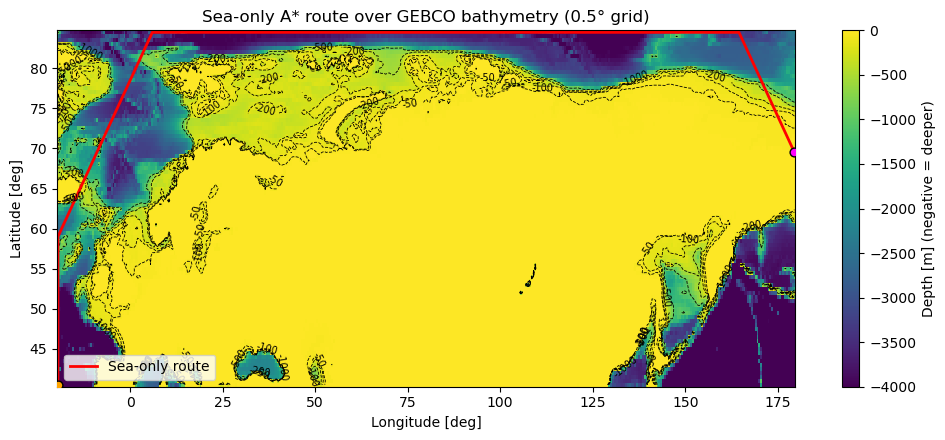

In [4]:
# -----------------------------------------
# FIGURE: depth_path_map (map with route + contours)
# -----------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))

im = ax.pcolormesh(
    lon_rg_2d, lat_rg_2d, depth_rg,
    cmap="viridis",
    shading="nearest",
    vmin=-4000, vmax=0
)
cbar = plt.colorbar(im, ax=ax, label="Depth [m] (negative = deeper)")

# Selected isobaths (negative values)
raw_levels = np.array([-50, -100, -200, -500, -1000])
cont_levels = np.sort(raw_levels)  # ensures strictly increasing

cs = ax.contour(
    lon_rg_2d, lat_rg_2d, depth_rg,
    levels=cont_levels,
    colors="k", linewidths=0.6, linestyles="dashed"
)
ax.clabel(cs, fmt="%d", fontsize=7)

# Plot route
ax.plot(route_lon, route_lat, "r-", linewidth=2.0, label="Sea-only route")

# Mark OD
ax.scatter(start_lon, start_lat, s=40, c="orange", edgecolor="k", zorder=5)
ax.scatter(goal_lon,  goal_lat,  s=40, c="magenta", edgecolor="k", zorder=5)

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Sea-only A* route over GEBCO bathymetry (0.5° grid)")

ax.legend(loc="lower left", framealpha=0.8)

plt.tight_layout()
plt.savefig("fig03_depth_path_map.png", dpi=300)
plt.show()

hmin=  20 m: depth-safe sea=0.938 of sea, components=27, route=True
hmin=  50 m: depth-safe sea=0.844 of sea, components=30, route=False
hmin= 100 m: depth-safe sea=0.760 of sea, components=35, route=False
hmin= 200 m: depth-safe sea=0.659 of sea, components=35, route=False


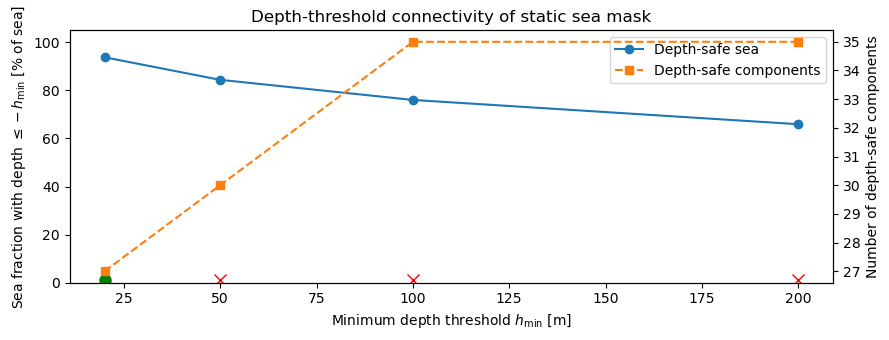

In [5]:
# -----------------------------------------
# FIGURE: depth_connectivity (sea fraction & components vs threshold)
# -----------------------------------------

depth_thresholds = [20.0, 50.0, 100.0, 200.0]  # metres

sea_fraction = sea_mask_rg.mean()

safe_fraction_list = []
n_components_list = []
route_exists_list = []

for hmin in depth_thresholds:
    # depth <= -hmin  (negative = depth)
    depth_safe_mask = np.logical_and(sea_mask_rg, depth_rg <= -hmin)

    safe_fraction = depth_safe_mask.mean()
    safe_fraction_list.append(safe_fraction)

    labels, ncomp = label(depth_safe_mask.astype(int), structure=np.ones((3, 3), dtype=int))
    n_components_list.append(ncomp)

    start_label = labels[start_idx]
    goal_label  = labels[goal_idx]
    route_exists = (start_label > 0) and (start_label == goal_label)
    route_exists_list.append(route_exists)

    print(f"hmin={hmin:4.0f} m: depth-safe sea={safe_fraction/sea_fraction:5.3f} of sea, "
          f"components={ncomp}, route={route_exists}")

# Plot
fig, ax1 = plt.subplots(figsize=(9, 3.5))

# Left axis: safe sea fraction (relative to total sea)
safe_pct = 100.0 * np.array(safe_fraction_list) / sea_fraction
ax1.plot(depth_thresholds, safe_pct, "o-", label="Depth-safe sea")
ax1.set_xlabel("Minimum depth threshold $h_{\\min}$ [m]")
ax1.set_ylabel("Sea fraction with depth $\\leq -h_{\\min}$ [% of sea]")
ax1.set_ylim(0, 105)

# connectivity markers at bottom
for h, ok in zip(depth_thresholds, route_exists_list):
    y = ax1.get_ylim()[0] + 1.0  # just above bottom
    ax1.plot(h, y, "go" if ok else "rx", ms=8)

# Right axis: number of components
ax2 = ax1.twinx()
ax2.plot(depth_thresholds, n_components_list, "s--", color="tab:orange",
         label="Depth-safe components")
ax2.set_ylabel("Number of depth-safe components")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Depth-threshold connectivity of static sea mask")

plt.tight_layout()
plt.savefig("fig04_depth_connectivity.png", dpi=300)
plt.show()